# Use scoring_bot env
# Used to tally points from extracted WhatsApp chat

In [1]:
import pandas as pd
import polars as pl
import re
from wordle_bot.scorer import ScoreCalculator as SC
from wordle_bot.whatsapp import WhatsAppClient
from datetime import datetime
from wordle_bot.parser import WordleParser as parser
import sqlite3
from wordle_bot.database import Database_wordle as DW
from wordle_bot.utils import plot_wordle_progress
import matplotlib.pyplot as plt

In [2]:
with open('WhatsApp Chat with Wordle Golf example.txt', 'r', encoding = 'utf-8') as f:
    lines = f.readlines()

for line in lines[80:120]:
    print(line.strip())

⬜🟩🟩🟩⬜
⬜🟩🟩🟩🟩
🟩🟩🟩🟩🟩
1/25/26, 8:48 PM - A: Wordle 1,682 4/6*

🟩⬛⬛⬛⬛
🟩🟩⬛🟨⬛
🟩🟩🟨⬛🟨
🟩🟩🟩🟩🟩
1/25/26, 11:50 PM - M: Wordle 1682 5/6*

⬛⬛🟨⬛🟨
⬛⬛🟩🟩🟨
⬛🟩🟩🟩⬛
⬛🟩🟩🟩🟩
🟩🟩🟩🟩🟩
1/26/26, 12:43 AM - C: Wordle 1,682 4/6

⬛🟩🟨⬛🟨
⬛🟩🟩🟩⬛
⬛🟩🟩🟩🟩
🟩🟩🟩🟩🟩
1/26/26, 12:44 AM - C: I feel like we made the same conclusion 🤣
1/26/26, 2:19 AM - D: Wordle 1,682 4/6*

⬜🟩🟨⬜🟨
🟨🟩🟩⬜⬜
⬜🟩🟩🟩⬜
🟩🟩🟩🟩🟩
1/26/26, 3:14 AM - P: Wordle 1,682 2/6*

🟨🟨⬛⬛🟨
🟩🟩🟩🟩🟩
1/26/26, 3:15 AM - Z: Wordle 1,682 4/6*

🟨⬛⬛⬛⬛
⬛⬛🟨🟩⬛
⬛⬛⬛🟩🟨
🟩🟩🟩🟩🟩
1/26/26, 11:29 AM - H: Wordle 1,682 4/6*


In [3]:
result_lines = parser.parser_wordle_score(lines)
print(result_lines[:5])

[('M', 1681, '3'), ('Z', 1681, '3'), ('P', 1681, '3'), ('C', 1681, '3'), ('A', 1681, '5')]


In [4]:
scores_extract = [SC(player, wordle, score) for player, wordle, score in result_lines]

In [5]:
print(scores_extract[:5])

[(player=M, wordle=1681, score=3)
, (player=Z, wordle=1681, score=3)
, (player=P, wordle=1681, score=3)
, (player=C, wordle=1681, score=3)
, (player=A, wordle=1681, score=5)
]


In [6]:
# run score cleaner on new extracts
df = SC.score_cleaner(scores_extract)
print(df)

shape: (1_385, 3)
┌────────┬────────────┬───────┐
│ player ┆ wordle_num ┆ score │
│ ---    ┆ ---        ┆ ---   │
│ str    ┆ i64        ┆ i64   │
╞════════╪════════════╪═══════╡
│ A      ┆ 1681       ┆ 5     │
│ C      ┆ 1681       ┆ 3     │
│ D      ┆ 1681       ┆ 3     │
│ H      ┆ 1681       ┆ 5     │
│ J      ┆ 1681       ┆ 5     │
│ …      ┆ …          ┆ …     │
│ H      ┆ 1853       ┆ null  │
│ J      ┆ 1853       ┆ null  │
│ M      ┆ 1853       ┆ 5     │
│ P      ┆ 1853       ┆ null  │
│ Z      ┆ 1853       ┆ null  │
└────────┴────────────┴───────┘


In [7]:
# Save scores to database
db = DW("scores.db")
db.save_score_if_missing_or_7(df)

Inserted lines: 0, Updated lines: 0.0, Existing lines: 1385


In [8]:
# Read scores from database and convert to DataFrame
df = db.load_scores(wordle_num=None, wordle_min=None, wordle_max=None)

print(df.tail(10))

shape: (10, 3)
┌────────┬────────────┬───────┐
│ player ┆ wordle_num ┆ score │
│ ---    ┆ ---        ┆ ---   │
│ str    ┆ i64        ┆ i64   │
╞════════╪════════════╪═══════╡
│ P      ┆ 1879       ┆ 4     │
│ Z      ┆ 1879       ┆ 5     │
│ A      ┆ 1880       ┆ 5     │
│ C      ┆ 1880       ┆ 4     │
│ D      ┆ 1880       ┆ 4     │
│ H      ┆ 1880       ┆ 6     │
│ J      ┆ 1880       ┆ 5     │
│ M      ┆ 1880       ┆ 3     │
│ P      ┆ 1880       ┆ 5     │
│ Z      ┆ 1880       ┆ 5     │
└────────┴────────────┴───────┘


In [9]:
def compute_weekly_score(df):
        """
        Calculate the total score for a player within all Wordle weeks, if wordle_week is complete.
        """

        weekly_dfs = []
        for week_start, week_end in SC.store_week_ranges(df):
        #    wordle_week = str(week_start) + '-' + str(week_end)
           df_week = df.filter(
               (pl.col("wordle_num") >= week_start) 
               & (pl.col("wordle_num") <= week_end)
           )
           weekly_dfs.append((df_week, week_start, week_end))

        # Filter out incomplete weeks (weeks that don't have all 7 days)
        if df.filter(pl.col("wordle_num") == pl.col("wordle_num").max() < weekly_dfs[-1][1]):
            weekly_dfs = weekly_dfs[:-1]


        weekly_scores = []

        for df_week, week_start, week_end in weekly_dfs:
            # wordle_week = f"{week_start}-{week_end}"
            weekly_score = df_week.group_by('player').agg(pl.sum('score')).sort('score')
            weekly_score = weekly_score.with_columns(
                            # pl.lit(wordle_week).alias("wordle_week"),
                            pl.lit(week_start).alias("week_start"),
                            pl.lit(week_end).alias("week_end")
                        )
            weekly_scores.append(weekly_score)
            



In [10]:
weekly_dfs = []
for week_start, week_end in SC.store_week_ranges(df):
#    wordle_week = str(week_start) + '-' + str(week_end)
   df_week = df.filter(
       (pl.col("wordle_num") >= week_start) 
       & (pl.col("wordle_num") <= week_end)
   )
   weekly_dfs.append((df_week, week_start, week_end))

In [11]:
print(len(weekly_dfs))
print(weekly_dfs[-1])

29
(shape: (32, 3)
┌────────┬────────────┬───────┐
│ player ┆ wordle_num ┆ score │
│ ---    ┆ ---        ┆ ---   │
│ str    ┆ i64        ┆ i64   │
╞════════╪════════════╪═══════╡
│ A      ┆ 1877       ┆ 4     │
│ C      ┆ 1877       ┆ 2     │
│ D      ┆ 1877       ┆ 5     │
│ H      ┆ 1877       ┆ 3     │
│ J      ┆ 1877       ┆ 4     │
│ …      ┆ …          ┆ …     │
│ H      ┆ 1880       ┆ 6     │
│ J      ┆ 1880       ┆ 5     │
│ M      ┆ 1880       ┆ 3     │
│ P      ┆ 1880       ┆ 5     │
│ Z      ┆ 1880       ┆ 5     │
└────────┴────────────┴───────┘, 1877, 1883)


In [13]:
weekly_scores = SC.week_ranking(df)
print(weekly_scores[-1])

shape: (8, 5)
┌────────┬───────┬────────────┬──────────┬──────┐
│ player ┆ score ┆ week_start ┆ week_end ┆ rank │
│ ---    ┆ ---   ┆ ---        ┆ ---      ┆ ---  │
│ str    ┆ i64   ┆ i32        ┆ i32      ┆ f64  │
╞════════╪═══════╪════════════╪══════════╪══════╡
│ M      ┆ 25    ┆ 1870       ┆ 1876     ┆ 1.0  │
│ H      ┆ 26    ┆ 1870       ┆ 1876     ┆ 2.0  │
│ J      ┆ 29    ┆ 1870       ┆ 1876     ┆ 3.0  │
│ C      ┆ 30    ┆ 1870       ┆ 1876     ┆ 4.0  │
│ Z      ┆ 31    ┆ 1870       ┆ 1876     ┆ 5.5  │
│ A      ┆ 31    ┆ 1870       ┆ 1876     ┆ 5.5  │
│ P      ┆ 35    ┆ 1870       ┆ 1876     ┆ 7.0  │
│ D      ┆ 36    ┆ 1870       ┆ 1876     ┆ 8.0  │
└────────┴───────┴────────────┴──────────┴──────┘


In [14]:
overall_score = SC.running_ranking(weekly_scores, interest="overall_score")
print(overall_score[-1])


for table in overall_score:

    db.save_leaderboard(table)

Leaderboard is empty or not found.
shape: (8, 7)
┌────────┬───────┬────────────┬──────────┬──────┬──────────────┬───────────────┐
│ player ┆ score ┆ week_start ┆ week_end ┆ rank ┆ overall_rank ┆ overall_score │
│ ---    ┆ ---   ┆ ---        ┆ ---      ┆ ---  ┆ ---          ┆ ---           │
│ str    ┆ i64   ┆ i32        ┆ i32      ┆ f64  ┆ f64          ┆ f64           │
╞════════╪═══════╪════════════╪══════════╪══════╪══════════════╪═══════════════╡
│ C      ┆ 30    ┆ 1870       ┆ 1876     ┆ 4.0  ┆ 84.5         ┆ 771.0         │
│ M      ┆ 25    ┆ 1870       ┆ 1876     ┆ 1.0  ┆ 90.0         ┆ 788.0         │
│ H      ┆ 26    ┆ 1870       ┆ 1876     ┆ 2.0  ┆ 112.0        ┆ 808.0         │
│ A      ┆ 31    ┆ 1870       ┆ 1876     ┆ 5.5  ┆ 122.5        ┆ 824.0         │
│ J      ┆ 29    ┆ 1870       ┆ 1876     ┆ 3.0  ┆ 128.5        ┆ 833.0         │
│ Z      ┆ 31    ┆ 1870       ┆ 1876     ┆ 5.5  ┆ 153.5        ┆ 856.0         │
│ D      ┆ 36    ┆ 1870       ┆ 1876     ┆ 8.0  ┆ 157.5     

In [15]:
overall_score_concat = pl.concat(overall_score)

print(overall_score_concat.tail(8))



shape: (8, 7)
┌────────┬───────┬────────────┬──────────┬──────┬──────────────┬───────────────┐
│ player ┆ score ┆ week_start ┆ week_end ┆ rank ┆ overall_rank ┆ overall_score │
│ ---    ┆ ---   ┆ ---        ┆ ---      ┆ ---  ┆ ---          ┆ ---           │
│ str    ┆ i64   ┆ i32        ┆ i32      ┆ f64  ┆ f64          ┆ f64           │
╞════════╪═══════╪════════════╪══════════╪══════╪══════════════╪═══════════════╡
│ C      ┆ 30    ┆ 1870       ┆ 1876     ┆ 4.0  ┆ 84.5         ┆ 771.0         │
│ M      ┆ 25    ┆ 1870       ┆ 1876     ┆ 1.0  ┆ 90.0         ┆ 788.0         │
│ H      ┆ 26    ┆ 1870       ┆ 1876     ┆ 2.0  ┆ 112.0        ┆ 808.0         │
│ A      ┆ 31    ┆ 1870       ┆ 1876     ┆ 5.5  ┆ 122.5        ┆ 824.0         │
│ J      ┆ 29    ┆ 1870       ┆ 1876     ┆ 3.0  ┆ 128.5        ┆ 833.0         │
│ Z      ┆ 31    ┆ 1870       ┆ 1876     ┆ 5.5  ┆ 153.5        ┆ 856.0         │
│ D      ┆ 36    ┆ 1870       ┆ 1876     ┆ 8.0  ┆ 157.5        ┆ 870.0         │
│ P      ┆ 35 

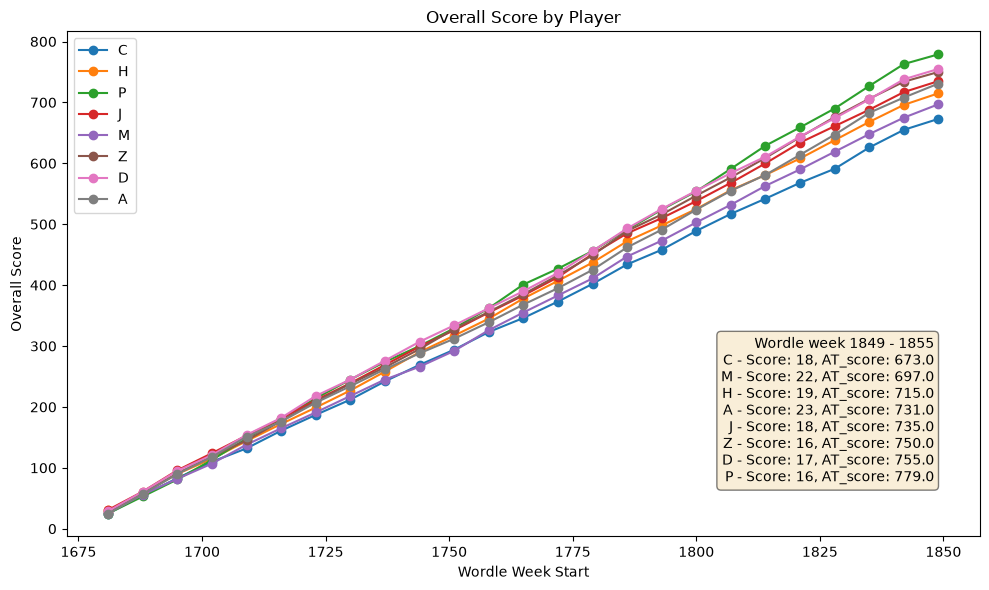

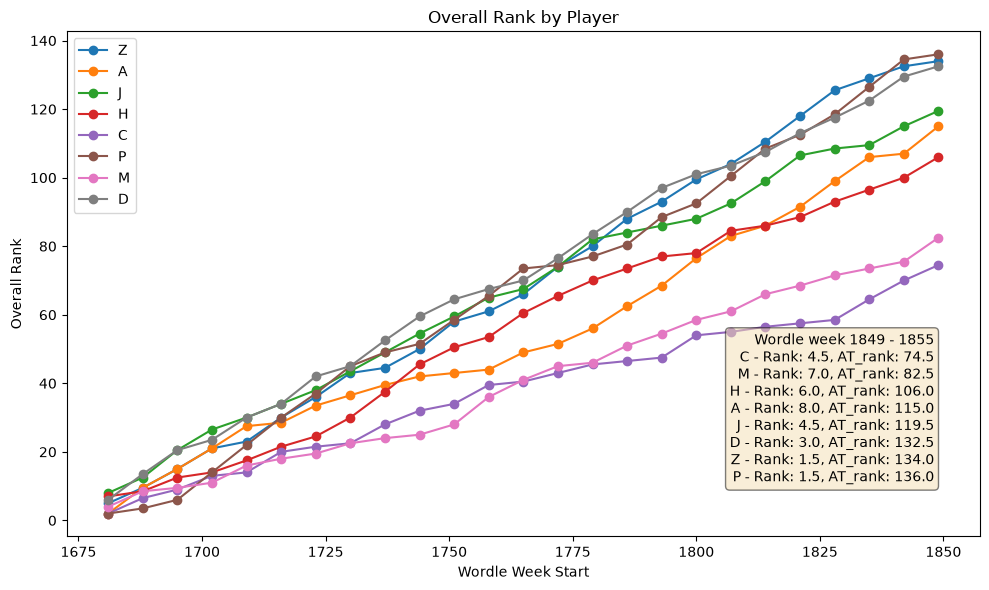

In [ ]:
plot_wordle_progress(overall_score_concat, mode="score")
plot_wordle_progress(overall_score_concat, mode="rank")

In [ ]:

text = df_to_whatsapp_score_rank(overall_score[-1])
print(f'{text} \n')

text1 = df_to_whatsapp_overall_score_rank(overall_score[-1])
print(text1)

Player     Week     Score   Rank
C      1849 - 1855    18   4.5
M      1849 - 1855    22   7.0
H      1849 - 1855    19   6.0
A      1849 - 1855    23   8.0
J      1849 - 1855    18   4.5
Z      1849 - 1855    16   1.5
D      1849 - 1855    17   3.0
P      1849 - 1855    16   1.5 

Player  AT Score  AT Rank
C           673.0     74.5
M           697.0     82.5
H           715.0    106.0
A           731.0    115.0
J           735.0    119.5
Z           750.0    134.0
D           755.0    132.5
P           779.0    136.0


In [ ]:
db = DW("scores.db")
get_leaderboard = db.load_leaderboard()
print(get_leaderboard)

shape: (200, 7)
┌────────┬────────────┬──────────┬───────┬──────┬──────────────┬───────────────┐
│ player ┆ week_start ┆ week_end ┆ score ┆ rank ┆ overall_rank ┆ overall_score │
│ ---    ┆ ---        ┆ ---      ┆ ---   ┆ ---  ┆ ---          ┆ ---           │
│ str    ┆ i64        ┆ i64      ┆ i64   ┆ f64  ┆ f64          ┆ f64           │
╞════════╪════════════╪══════════╪═══════╪══════╪══════════════╪═══════════════╡
│ P      ┆ 1681       ┆ 1687     ┆ 25    ┆ 2.0  ┆ 2.0          ┆ 25.0          │
│ C      ┆ 1681       ┆ 1687     ┆ 25    ┆ 2.0  ┆ 2.0          ┆ 25.0          │
│ A      ┆ 1681       ┆ 1687     ┆ 25    ┆ 2.0  ┆ 2.0          ┆ 25.0          │
│ M      ┆ 1681       ┆ 1687     ┆ 26    ┆ 4.0  ┆ 4.0          ┆ 26.0          │
│ Z      ┆ 1681       ┆ 1687     ┆ 28    ┆ 5.0  ┆ 5.0          ┆ 28.0          │
│ …      ┆ …          ┆ …        ┆ …     ┆ …    ┆ …            ┆ …             │
│ A      ┆ 1849       ┆ 1855     ┆ 23    ┆ 8.0  ┆ 115.0        ┆ 731.0         │
│ J      ┆ 1

In [ ]:
db = DW("scores.db")
latest = db.get_latest_wordle_num()
print(f'Latest Wordle number: {latest}')

Latest Wordle number: 1853


In [ ]:
new_scores = ["J", 1865, 3], ["K", 1865, 4], ["N", 1865, "X"], ["C", 1864, 2]

new_scores_df = pl.DataFrame(new_scores, schema=["player", "wordle_num", "score"])
print(new_scores_df)

cleaned_scores = SC.score_cleaner(new_scores_df)
print(cleaned_scores)

shape: (4, 3)
┌────────┬────────────┬───────┐
│ player ┆ wordle_num ┆ score │
│ ---    ┆ ---        ┆ ---   │
│ str    ┆ i64        ┆ str   │
╞════════╪════════════╪═══════╡
│ J      ┆ 1865       ┆ 3     │
│ K      ┆ 1865       ┆ 4     │
│ N      ┆ 1865       ┆ X     │
│ C      ┆ 1864       ┆ 2     │
└────────┴────────────┴───────┘
shape: (8, 3)
┌────────┬────────────┬───────┐
│ player ┆ wordle_num ┆ score │
│ ---    ┆ ---        ┆ ---   │
│ str    ┆ i64        ┆ i64   │
╞════════╪════════════╪═══════╡
│ C      ┆ 1864       ┆ 2     │
│ J      ┆ 1864       ┆ 7     │
│ K      ┆ 1864       ┆ 7     │
│ N      ┆ 1864       ┆ 7     │
│ C      ┆ 1865       ┆ null  │
│ J      ┆ 1865       ┆ 3     │
│ K      ┆ 1865       ┆ 4     │
│ N      ┆ 1865       ┆ 7     │
└────────┴────────────┴───────┘


/tmp/ipykernel_45353/3926229805.py:3: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  new_scores_df = pl.DataFrame(new_scores, schema=["player", "wordle_num", "score"])


In [ ]:
df_test = pl.DataFrame({"wordle_num": [1853]})
calc_limit = SC.store_week_ranges(df_test)[0][0]
print(f'calc_limit: {calc_limit}')

calc_limit: 1849


In [ ]:
db = DW("scores.db")
scores_df = db.load_scores()

scores_recent = scores_df.filter(pl.col('wordle_num') >= calc_limit)

print(scores_recent)



shape: (152, 3)
┌────────┬────────────┬───────┐
│ player ┆ wordle_num ┆ score │
│ ---    ┆ ---        ┆ ---   │
│ str    ┆ i64        ┆ i64   │
╞════════╪════════════╪═══════╡
│ A      ┆ 1849       ┆ 6     │
│ C      ┆ 1849       ┆ 6     │
│ D      ┆ 1849       ┆ 4     │
│ H      ┆ 1849       ┆ 5     │
│ J      ┆ 1849       ┆ 7     │
│ …      ┆ …          ┆ …     │
│ H      ┆ 1867       ┆ 4     │
│ J      ┆ 1867       ┆ 4     │
│ M      ┆ 1867       ┆ null  │
│ P      ┆ 1867       ┆ 3     │
│ Z      ┆ 1867       ┆ 5     │
└────────┴────────────┴───────┘


In [ ]:
# calculate the leaderboard from new scores
week_rank = SC.week_ranking(scores_recent)
print(week_rank)

[shape: (8, 5)
┌────────┬───────┬────────────┬──────────┬──────┐
│ player ┆ score ┆ week_start ┆ week_end ┆ rank │
│ ---    ┆ ---   ┆ ---        ┆ ---      ┆ ---  │
│ str    ┆ i64   ┆ i32        ┆ i32      ┆ f64  │
╞════════╪═══════╪════════════╪══════════╪══════╡
│ J      ┆ 27    ┆ 1849       ┆ 1855     ┆ 1.0  │
│ Z      ┆ 29    ┆ 1849       ┆ 1855     ┆ 2.0  │
│ H      ┆ 30    ┆ 1849       ┆ 1855     ┆ 3.0  │
│ P      ┆ 31    ┆ 1849       ┆ 1855     ┆ 5.0  │
│ C      ┆ 31    ┆ 1849       ┆ 1855     ┆ 5.0  │
│ M      ┆ 31    ┆ 1849       ┆ 1855     ┆ 5.0  │
│ D      ┆ 33    ┆ 1849       ┆ 1855     ┆ 7.0  │
│ A      ┆ 37    ┆ 1849       ┆ 1855     ┆ 8.0  │
└────────┴───────┴────────────┴──────────┴──────┘, shape: (8, 5)
┌────────┬───────┬────────────┬──────────┬──────┐
│ player ┆ score ┆ week_start ┆ week_end ┆ rank │
│ ---    ┆ ---   ┆ ---        ┆ ---      ┆ ---  │
│ str    ┆ i64   ┆ i32        ┆ i32      ┆ f64  │
╞════════╪═══════╪════════════╪══════════╪══════╡
│ A      ┆ 27    ┆ 1

In [ ]:
leaderboard = db.load_leaderboard()
# print(current_leaderboard.tail(8))

current_leaderboard = leaderboard.tail(8)

print(current_leaderboard)

shape: (8, 7)
┌────────┬────────────┬──────────┬───────┬──────┬──────────────┬───────────────┐
│ player ┆ week_start ┆ week_end ┆ score ┆ rank ┆ overall_rank ┆ overall_score │
│ ---    ┆ ---        ┆ ---      ┆ ---   ┆ ---  ┆ ---          ┆ ---           │
│ str    ┆ i64        ┆ i64      ┆ i64   ┆ f64  ┆ f64          ┆ f64           │
╞════════╪════════════╪══════════╪═══════╪══════╪══════════════╪═══════════════╡
│ C      ┆ 1849       ┆ 1855     ┆ 18    ┆ 4.5  ┆ 74.5         ┆ 673.0         │
│ M      ┆ 1849       ┆ 1855     ┆ 22    ┆ 7.0  ┆ 82.5         ┆ 697.0         │
│ H      ┆ 1849       ┆ 1855     ┆ 19    ┆ 6.0  ┆ 106.0        ┆ 715.0         │
│ A      ┆ 1849       ┆ 1855     ┆ 23    ┆ 8.0  ┆ 115.0        ┆ 731.0         │
│ J      ┆ 1849       ┆ 1855     ┆ 18    ┆ 4.5  ┆ 119.5        ┆ 735.0         │
│ Z      ┆ 1849       ┆ 1855     ┆ 16    ┆ 1.5  ┆ 134.0        ┆ 750.0         │
│ D      ┆ 1849       ┆ 1855     ┆ 17    ┆ 3.0  ┆ 132.5        ┆ 755.0         │
│ P      ┆ 184

In [ ]:
overall_score = SC.running_ranking(week_rank, interest="overall_score", database=db)
print(overall_score)

[shape: (8, 7)
┌────────┬───────┬────────────┬──────────┬──────┬──────────────┬───────────────┐
│ player ┆ score ┆ week_start ┆ week_end ┆ rank ┆ overall_rank ┆ overall_score │
│ ---    ┆ ---   ┆ ---        ┆ ---      ┆ ---  ┆ ---          ┆ ---           │
│ str    ┆ i64   ┆ i32        ┆ i32      ┆ f64  ┆ f64          ┆ f64           │
╞════════╪═══════╪════════════╪══════════╪══════╪══════════════╪═══════════════╡
│ C      ┆ 31    ┆ 1849       ┆ 1855     ┆ 5.0  ┆ 79.5         ┆ 704.0         │
│ M      ┆ 31    ┆ 1849       ┆ 1855     ┆ 5.0  ┆ 87.5         ┆ 728.0         │
│ H      ┆ 30    ┆ 1849       ┆ 1855     ┆ 3.0  ┆ 109.0        ┆ 745.0         │
│ J      ┆ 27    ┆ 1849       ┆ 1855     ┆ 1.0  ┆ 120.5        ┆ 762.0         │
│ A      ┆ 37    ┆ 1849       ┆ 1855     ┆ 8.0  ┆ 123.0        ┆ 768.0         │
│ Z      ┆ 29    ┆ 1849       ┆ 1855     ┆ 2.0  ┆ 136.0        ┆ 779.0         │
│ D      ┆ 33    ┆ 1849       ┆ 1855     ┆ 7.0  ┆ 139.5        ┆ 788.0         │
│ P      ┆ 31

In [ ]:

for table in overall_score:

    db.save_leaderboard(table)

In [ ]:
print(scores_recent.select(pl.col("wordle_num")).max().item())

1867


In [ ]:
print(overall_score[0]['week_end'][0])

1855
